In [2]:
import pandas as pd
import numpy as np

# Active learning performance figure
rounds = list(range(1, 9))
models = ["YOLOv8n", "YOLOv8s"] + ["YOLOv8m"] * 6
map_0_5 = [0.25, 0.33, 0.44, 0.6, 0.67, 0.70, 0.72, 0.73]
map_0_95 = [0.11, 0.17, 0.22, 0.35, 0.38, 0.39, 0.41, 0.43]
dataset_additions = [10, 20, 40, 80, 160, 320, 640, 1280]
dataset_size = np.cumsum(dataset_additions)

al_performance_df = pd.DataFrame(data={"Round": rounds, "Model": models, "mAP@0.5": map_0_5, "mAP@0.5:0.95": map_0_95, "Dataset Size": dataset_size})
al_performance_df

,Round,Model,mAP@0.5,mAP@0.5:0.95,Dataset Size
0,1,YOLOv8n,0.25,0.11,10
1,2,YOLOv8s,0.33,0.17,30
2,3,YOLOv8m,0.44,0.22,70
3,4,YOLOv8m,0.60,0.35,150
4,5,YOLOv8m,0.67,0.38,310
5,6,YOLOv8m,0.70,0.39,630
6,7,YOLOv8m,0.72,0.41,1270
7,8,YOLOv8m,0.73,0.43,2550


2024-12-11 12:03:02,084 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-12-11 12:03:02,087 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


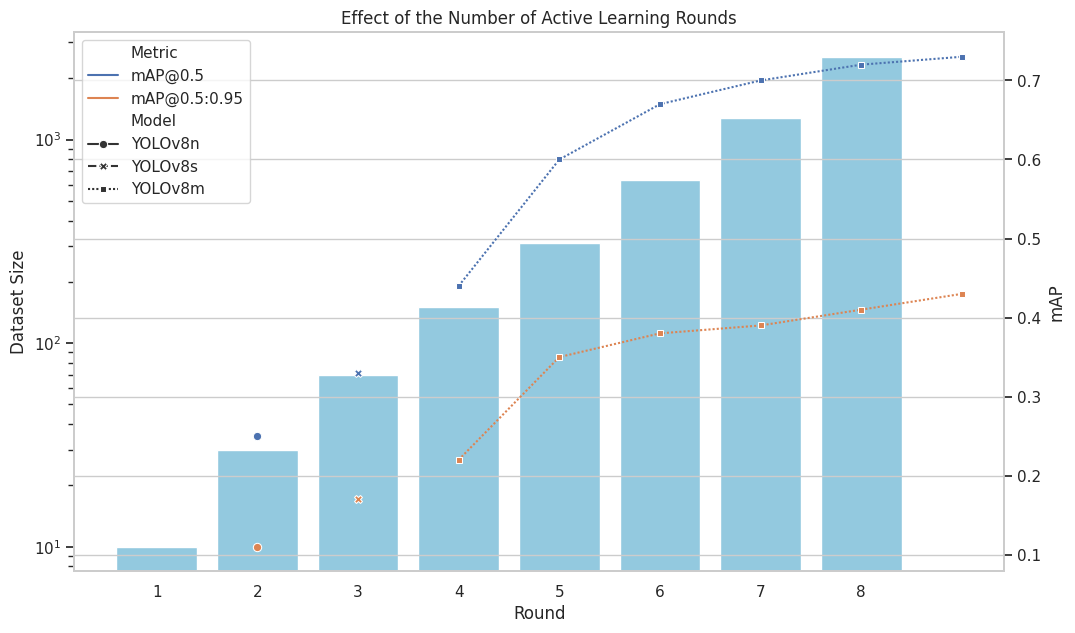

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Melt the DataFrame to have a single "Metric" column for different mAP types
al_performance_melted = al_performance_df.melt(id_vars=['Round', 'Model'], var_name='Metric', value_name='mAP', value_vars=["mAP@0.5", "mAP@0.5:0.95"])

# Plot the dataset size.
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(ax=ax1, data=al_performance_df, x="Round", y="Dataset Size", color="skyblue")
# Don't show the grid lines, because they interfere with the other y-axis.
ax1.grid(False)
# Use log scale.
ax1.set_yscale("log")

# Create the line plot on top.
ax2 = ax1.twinx()
sns.lineplot(ax=ax2,data=al_performance_melted, x='Round', y='mAP', hue='Metric', style='Model', markers=True)

plt.title('Effect of the Number of Active Learning Rounds')
plt.xlabel('Round')
plt.ylabel('mAP')
plt.show()

In [4]:
# Create ablation experiments plot.
ablation_data = pd.read_excel("Experiments.xlsx", sheet_name="Ablation", true_values={"Y"}, false_values={"N"})
ablation_data

,Int8,KF,Anchor Box,RoI Detection,2-Stage Association,Conf. Threshold,IoU Threshold,Death Window,Keyframe Period,Video,Unnamed: 10,HOTA,IDF1,Speed (FPS)
0,False,False,False,False,False,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,68.83,80.90,13.67
1,False,False,False,False,False,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,47.29,66.08,19.04
2,False,False,False,False,True,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,68.83,80.90,18.71
3,False,False,False,False,True,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,47.30,66.08,22.13
4,False,True,False,False,True,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,69.92,83.30,20.35
5,False,True,False,False,True,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,48.55,69.51,22.79
6,False,True,True,False,True,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,69.92,83.30,19.80
7,False,True,True,False,True,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,48.55,69.51,22.01
8,False,True,True,True,True,0.70,0.25,1,0.1,2022-08-23_ENGR,NaN,67.71,81.52,31.98
9,False,True,True,True,True,0.70,0.25,1,0.1,2021-08-25_SPL,NaN,46.73,67.43,71.75


In [5]:
def get_config(row: pd.Series) -> str:
    config = "Base"
    if row["Int8"]:
        config = "I"
    if row["2-Stage Association"]:
        if config == "I":
            config += "+2SA"
        else:
            # Replace the base specifier.
            config = "2SA"
    if row["KF"]:
        config += "+KF"
    if row["Anchor Box"]:
        config += "+AB"
    if row["RoI Detection"]:
        config += "+RoI"
    
    return config

ablation_data["Config"] = ablation_data.apply(get_config, axis=1)

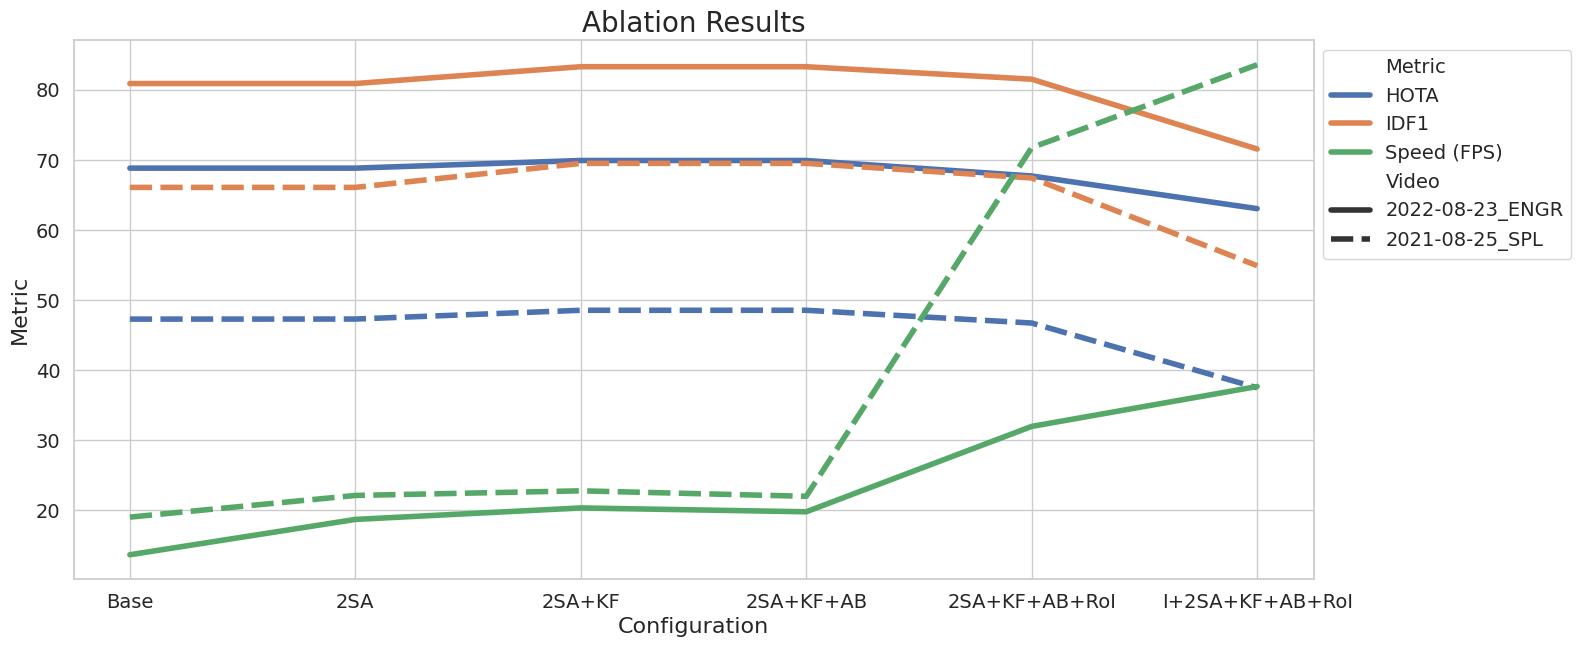

In [12]:
# Set seaborn style
sns.set(style="whitegrid")

# Melt the DataFrame to have a single "Metric" column for different metrics
ablation_data_slice = ablation_data[["Video", "HOTA", "IDF1", "Speed (FPS)", "Config"]]
ablation_data_melted = ablation_data_slice.melt(id_vars=['Config', 'Video'], var_name='Metric', value_name='Value')

# Create the line plot
plt.figure(figsize=(16, 7))
sns.lineplot(data=ablation_data_melted, x='Config', y='Value', hue='Metric', style='Video', markers=False, linewidth=4)
plt.title('Ablation Results', fontsize=20)
plt.xlabel('Configuration', fontsize=16)
plt.ylabel('Metric', fontsize=16)

# Increase font size of axis ticks
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=14)
plt.show()


In [13]:
# Create parameter search plots.
search_data = pd.read_excel("Experiments.xlsx", sheet_name="Parameter Search")
search_data

,Conf. Threshold,IoU Threshold,Death Window,Keyframe Period,Video,Unnamed: 5,HOTA,IDF1,Speed (FPS)
0,0.200,0.25,1,0.10,2022-08-23_ENGR,NaN,45.40,52.35,48.20
1,0.200,0.25,1,0.10,2021-08-25_SPL,NaN,26.53,31.49,103.81
2,0.050,0.25,1,0.10,2022-08-23_ENGR,NaN,59.00,67.55,42.70
3,0.050,0.25,1,0.10,2021-08-25_SPL,NaN,32.47,44.30,95.18
4,0.100,0.50,1,0.10,2022-08-23_ENGR,NaN,55.68,63.66,41.33
5,0.100,0.50,1,0.10,2021-08-25_SPL,NaN,30.20,39.58,100.22
6,0.100,0.10,1,0.10,2022-08-23_ENGR,NaN,55.68,63.66,44.77
7,0.100,0.10,1,0.10,2021-08-25_SPL,NaN,30.20,39.58,97.55
8,0.100,0.25,2,0.10,2022-08-23_ENGR,NaN,55.68,63.66,43.87
9,0.100,0.25,2,0.10,2021-08-25_SPL,NaN,30.22,39.80,96.61


In [18]:
BASE_CONF = 0.1
BASE_IOU = 0.25
BASE_DW = 1
BASE_KFP = 0.1

# Remove the field names from the video names.
search_data_clean = search_data.drop("Unnamed: 5", axis=1)
search_data_clean["Video"] = search_data_clean["Video"].apply(lambda s: s.split("_")[0])

# Melt all the metrics.
search_data_melted = search_data_clean.melt(id_vars=search_data_clean.columns[:-3], var_name="Metric", value_name="Value")

base_conf = search_data_melted["Conf. Threshold"] == BASE_CONF
base_iou = search_data_melted["IoU Threshold"] == BASE_IOU
base_dw = search_data_melted["Death Window"] == BASE_DW
base_kfp = search_data_melted["Keyframe Period"] == BASE_KFP

search_conf = search_data_melted[base_iou & base_dw & base_kfp]
search_iou = search_data_melted[base_conf & base_dw & base_kfp]
search_dw = search_data_melted[base_conf & base_iou & base_kfp]
search_kfp = search_data_melted[base_conf & base_iou & base_dw]

2024-12-11 17:43:11,062 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-12-11 17:43:11,067 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 1200x600 with 0 Axes>

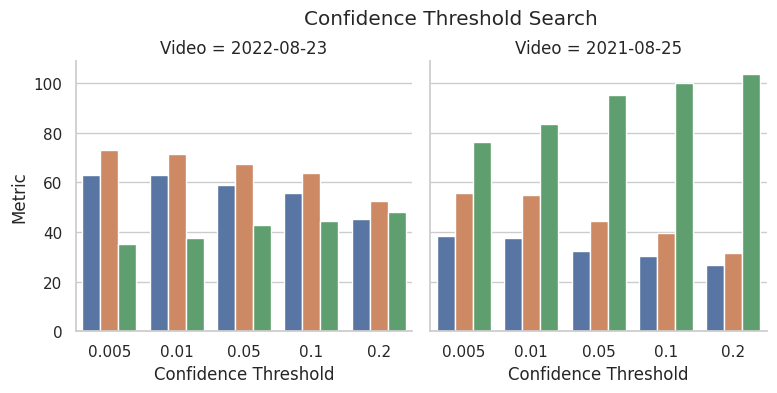

In [20]:
# Confidence threshold search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_conf, x='Conf. Threshold', y='Value', hue='Metric', col='Video', height=4, aspect=1)
# Remove the legend
grid._legend.remove()
grid.fig.suptitle('Confidence Threshold Search')

# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("Confidence Threshold", "Metric")
plt.show()

2024-12-11 17:43:26,783 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-12-11 17:43:26,788 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 1200x400 with 0 Axes>

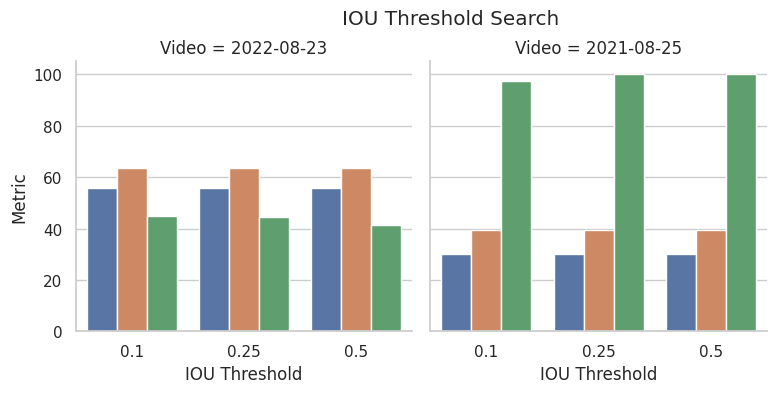

In [21]:
# IOU threshold search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 4))
grid = sns.catplot(kind="bar", data=search_iou, x='IoU Threshold', y='Value', hue='Metric', col='Video', height=4, aspect=1)
# Remove the legend
grid._legend.remove()
grid.fig.suptitle('IOU Threshold Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("IOU Threshold", "Metric")
plt.show()

2024-12-11 17:49:06,745 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-12-11 17:49:06,750 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 1200x600 with 0 Axes>

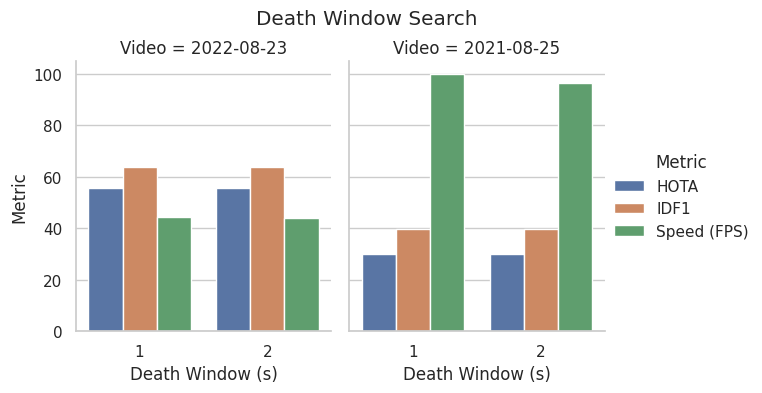

In [27]:
# Death window search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_dw, x='Death Window', y='Value', hue='Metric', col='Video', height=4, aspect=0.8)
grid.fig.suptitle('Death Window Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("Death Window (s)", "Metric")
plt.show()

2024-12-11 17:43:36,665 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-12-11 17:43:36,669 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 1200x600 with 0 Axes>

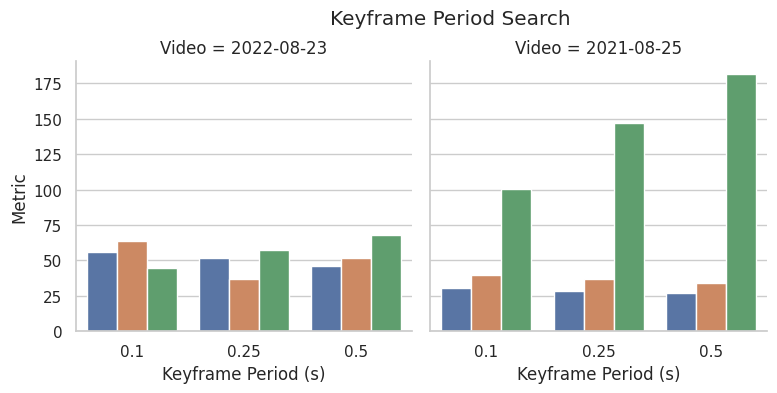

In [22]:
# Keyframe period search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_kfp, x='Keyframe Period', y='Value', hue='Metric', col='Video', height=4, aspect=1)
# Remove the legend
grid._legend.remove()
grid.fig.suptitle('Keyframe Period Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("Keyframe Period (s)", "Metric")
plt.show()

In [35]:
# Profiling pie chart
profile_data = pd.read_csv("profile_data_2021-08-25.txt", sep=" ", skipinitialspace=True, names=["Name", "Time", "Num Iters", "Cycle Time", "Cycle Freq"])
profile_data

,Name,Time,Num Iters,Cycle Time,Cycle Freq
0,match_frame_pair,408.737000,34229,0.011941,83.7432
1,detection,285.504000,34229,0.008341,119.8900
2,create_detection_inputs,0.632884,6198,0.000102,9793.2600
3,detection_model_full,185.042000,6198,0.029855,33.4950
4,filter_low_confidence,5.662960,34229,0.000165,6044.3600
5,update_tracks,36.150400,34229,0.001056,946.8510
6,update_active_tracks,20.779300,34229,0.000607,1647.2600
7,add_new_tracks,1.785230,34229,0.000052,19173.4000
8,update_saved_state,1.527790,34229,0.000045,22404.2000
9,roi_extraction,21.239600,28031,0.000758,1319.7500


In [36]:
def get_profiles(raw_profile_data: pd.DataFrame):
    raw_profile_data = raw_profile_data.copy()
    name = raw_profile_data["Name"]
    
    # Motion model is included in update_track time, so subtract that.
    raw_profile_data.loc[name == "update_tracks", "Time"] -= raw_profile_data.loc[name == "motion_model", "Time"].to_numpy()[0]
    
    profile_detection = raw_profile_data[(name == "detection") | (name == "create_detection_inputs") | (name == "filter_low_confidence")]
    profile_tracking = raw_profile_data[(name == "update_tracks") | (name == "fast_association") | (name == "motion_model") | (name == "slow_association")]
    profile_detection_details = raw_profile_data[(name == "detection_model_full") | (name == "roi_extraction") | (name == "detection_model_roi")]
    
    return profile_detection, profile_tracking, profile_detection_details

In [37]:
_NAME_MAP = {"detection_model_full": "Full Image Detector", "detection_model_roi": "RoI Detector", "roi_extraction": "Extract RoIs", 
             "update_tracks": "Track Bookkeeping", "slow_association": "GNN Association", "fast_association": "IOU Association",
             "motion_model": "Kalman Filter"}
def human_readable_names(name: str) -> str:
    return _NAME_MAP.get(name, name)

In [38]:
detection, tracking, detection_details = get_profiles(profile_data)

# Convert to human-readable names.
detection.loc[:, "Name"] = detection["Name"].apply(human_readable_names)
tracking.loc[:, "Name"] = tracking["Name"].apply(human_readable_names)
detection_details.loc[:, "Name"] = detection_details["Name"].apply(human_readable_names)

detection_time = detection.sum()["Time"]
tracking_time = tracking.sum()["Time"]

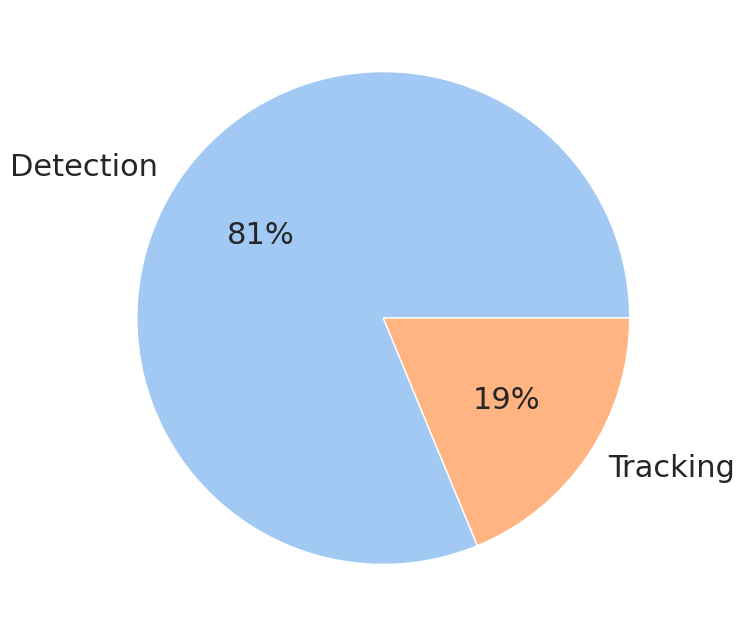

In [39]:
plt.figure(figsize=(8, 8))

# Overall detection and tracking
colors = sns.color_palette('pastel')[0:5]
plt.pie([detection_time, tracking_time], labels=["Detection", "Tracking"], autopct='%.0f%%', colors=colors, textprops={'fontsize': 22})

plt.show()

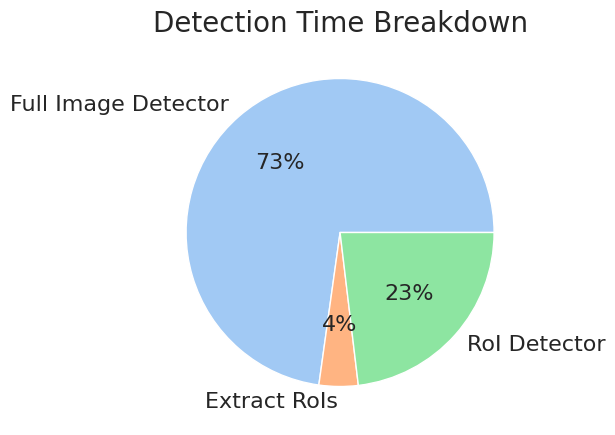

In [32]:
plt.figure(figsize=(5, 5))

# Detection breakdown
plt.pie(detection_details["Time"], labels=detection_details["Name"], autopct='%.0f%%', colors=colors, textprops={'fontsize': 16})
plt.title("Detection Time Breakdown", fontsize=20)
plt.show()

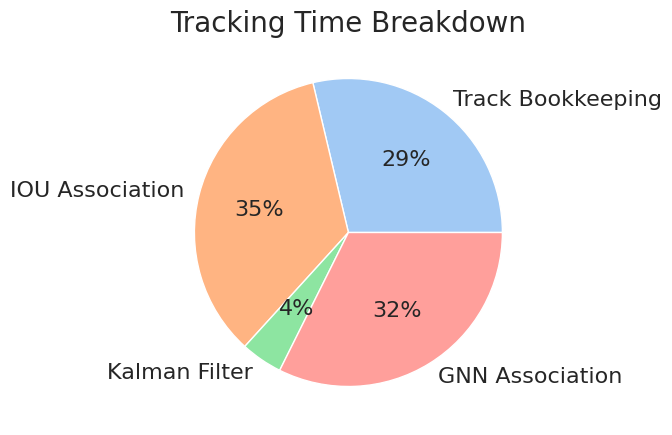

In [33]:
plt.figure(figsize=(5, 5))

# Tracking breakdown
plt.pie(tracking["Time"], labels=tracking["Name"], autopct='%.0f%%', colors=colors, textprops={'fontsize': 16})
plt.title("Tracking Time Breakdown", fontsize=20)
plt.show()

In [47]:
flower_count_data = pd.read_excel("Count Evaluation.xlsx", sheet_name="Combined")
flower_count_data

,Plot,Real,Predicted,Error,Sum,Ratio,Unnamed: 6,MAE,SMAPE
0,1,3,2,1,5,0.200000,NaN,0.555556,19.340284
1,2,1,1,0,2,0.000000,NaN,NaN,NaN
2,3,0,0,0,0,0.000000,NaN,NaN,NaN
3,4,3,2,1,5,0.200000,NaN,NaN,NaN
4,5,0,0,0,0,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
61,8,3,1,2,4,0.500000,NaN,NaN,NaN
62,9,13,11,2,24,0.083333,NaN,NaN,NaN
63,10,7,7,0,14,0.000000,NaN,NaN,NaN
64,11,10,6,4,16,0.250000,NaN,NaN,NaN


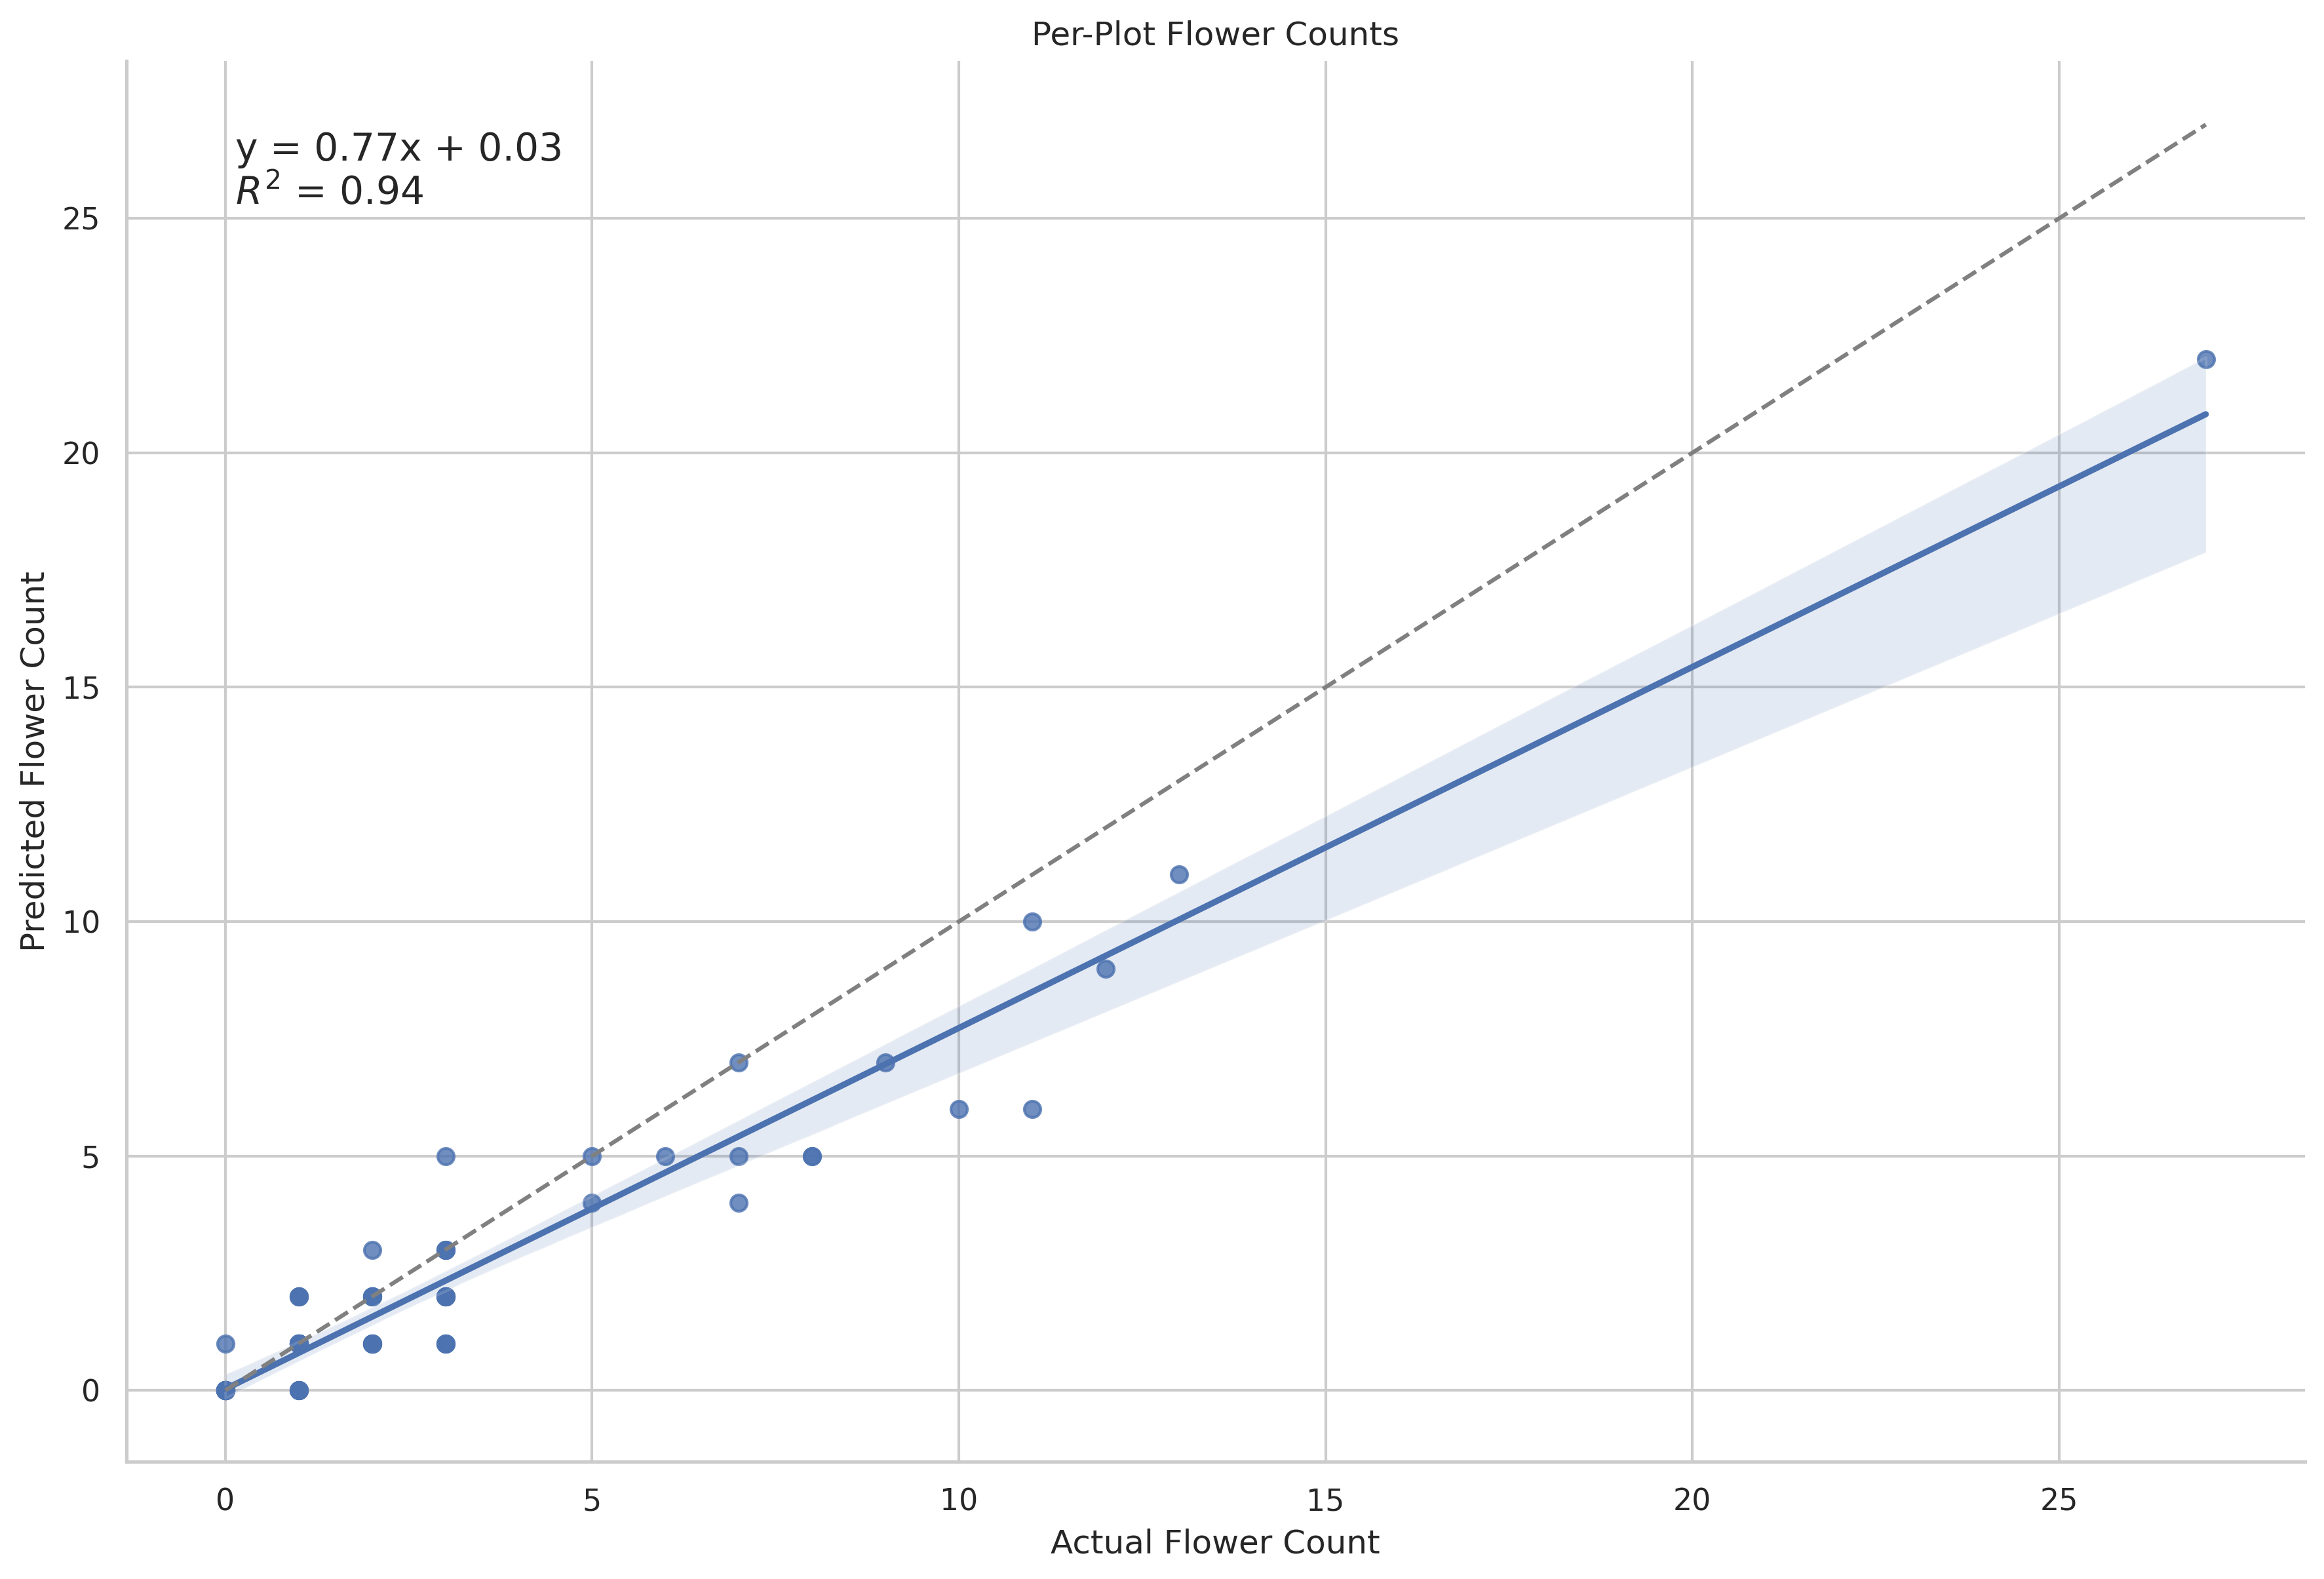

In [55]:
import numpy as np

# Create a scatter plot with a line of best fit.
lmplot = sns.lmplot(x='Real', y='Predicted', data=flower_count_data, height=8, aspect=1.5)

# Calculate the coefficients for the line of best fit
slope, intercept = np.polyfit(flower_count_data['Real'], flower_count_data['Predicted'], 1)

# Calculate R-squared value
residuals = flower_count_data['Predicted'] - (slope * flower_count_data['Real'] + intercept)
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((flower_count_data['Predicted'] - np.mean(flower_count_data['Predicted'])) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Plot the line of best fit equation and R-squared value
plt.annotate(f'y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_squared:.2f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=14, ha='left', va='top')

# Add the 1:1 line
plt.plot([0, 27], [0, 27], linestyle='--', color='gray')

# Set labels and title
plt.xlabel('Actual Flower Count')
plt.ylabel('Predicted Flower Count')
plt.title('Per-Plot Flower Counts')

lmplot.fig.set_dpi(300)

# Show the plot
plt.show()


2024-07-26 09:50:57,168 - py.warnings - WARNING - /tmp/ipykernel_261783/123197582.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Model', y='Size', data=df, palette=colors)



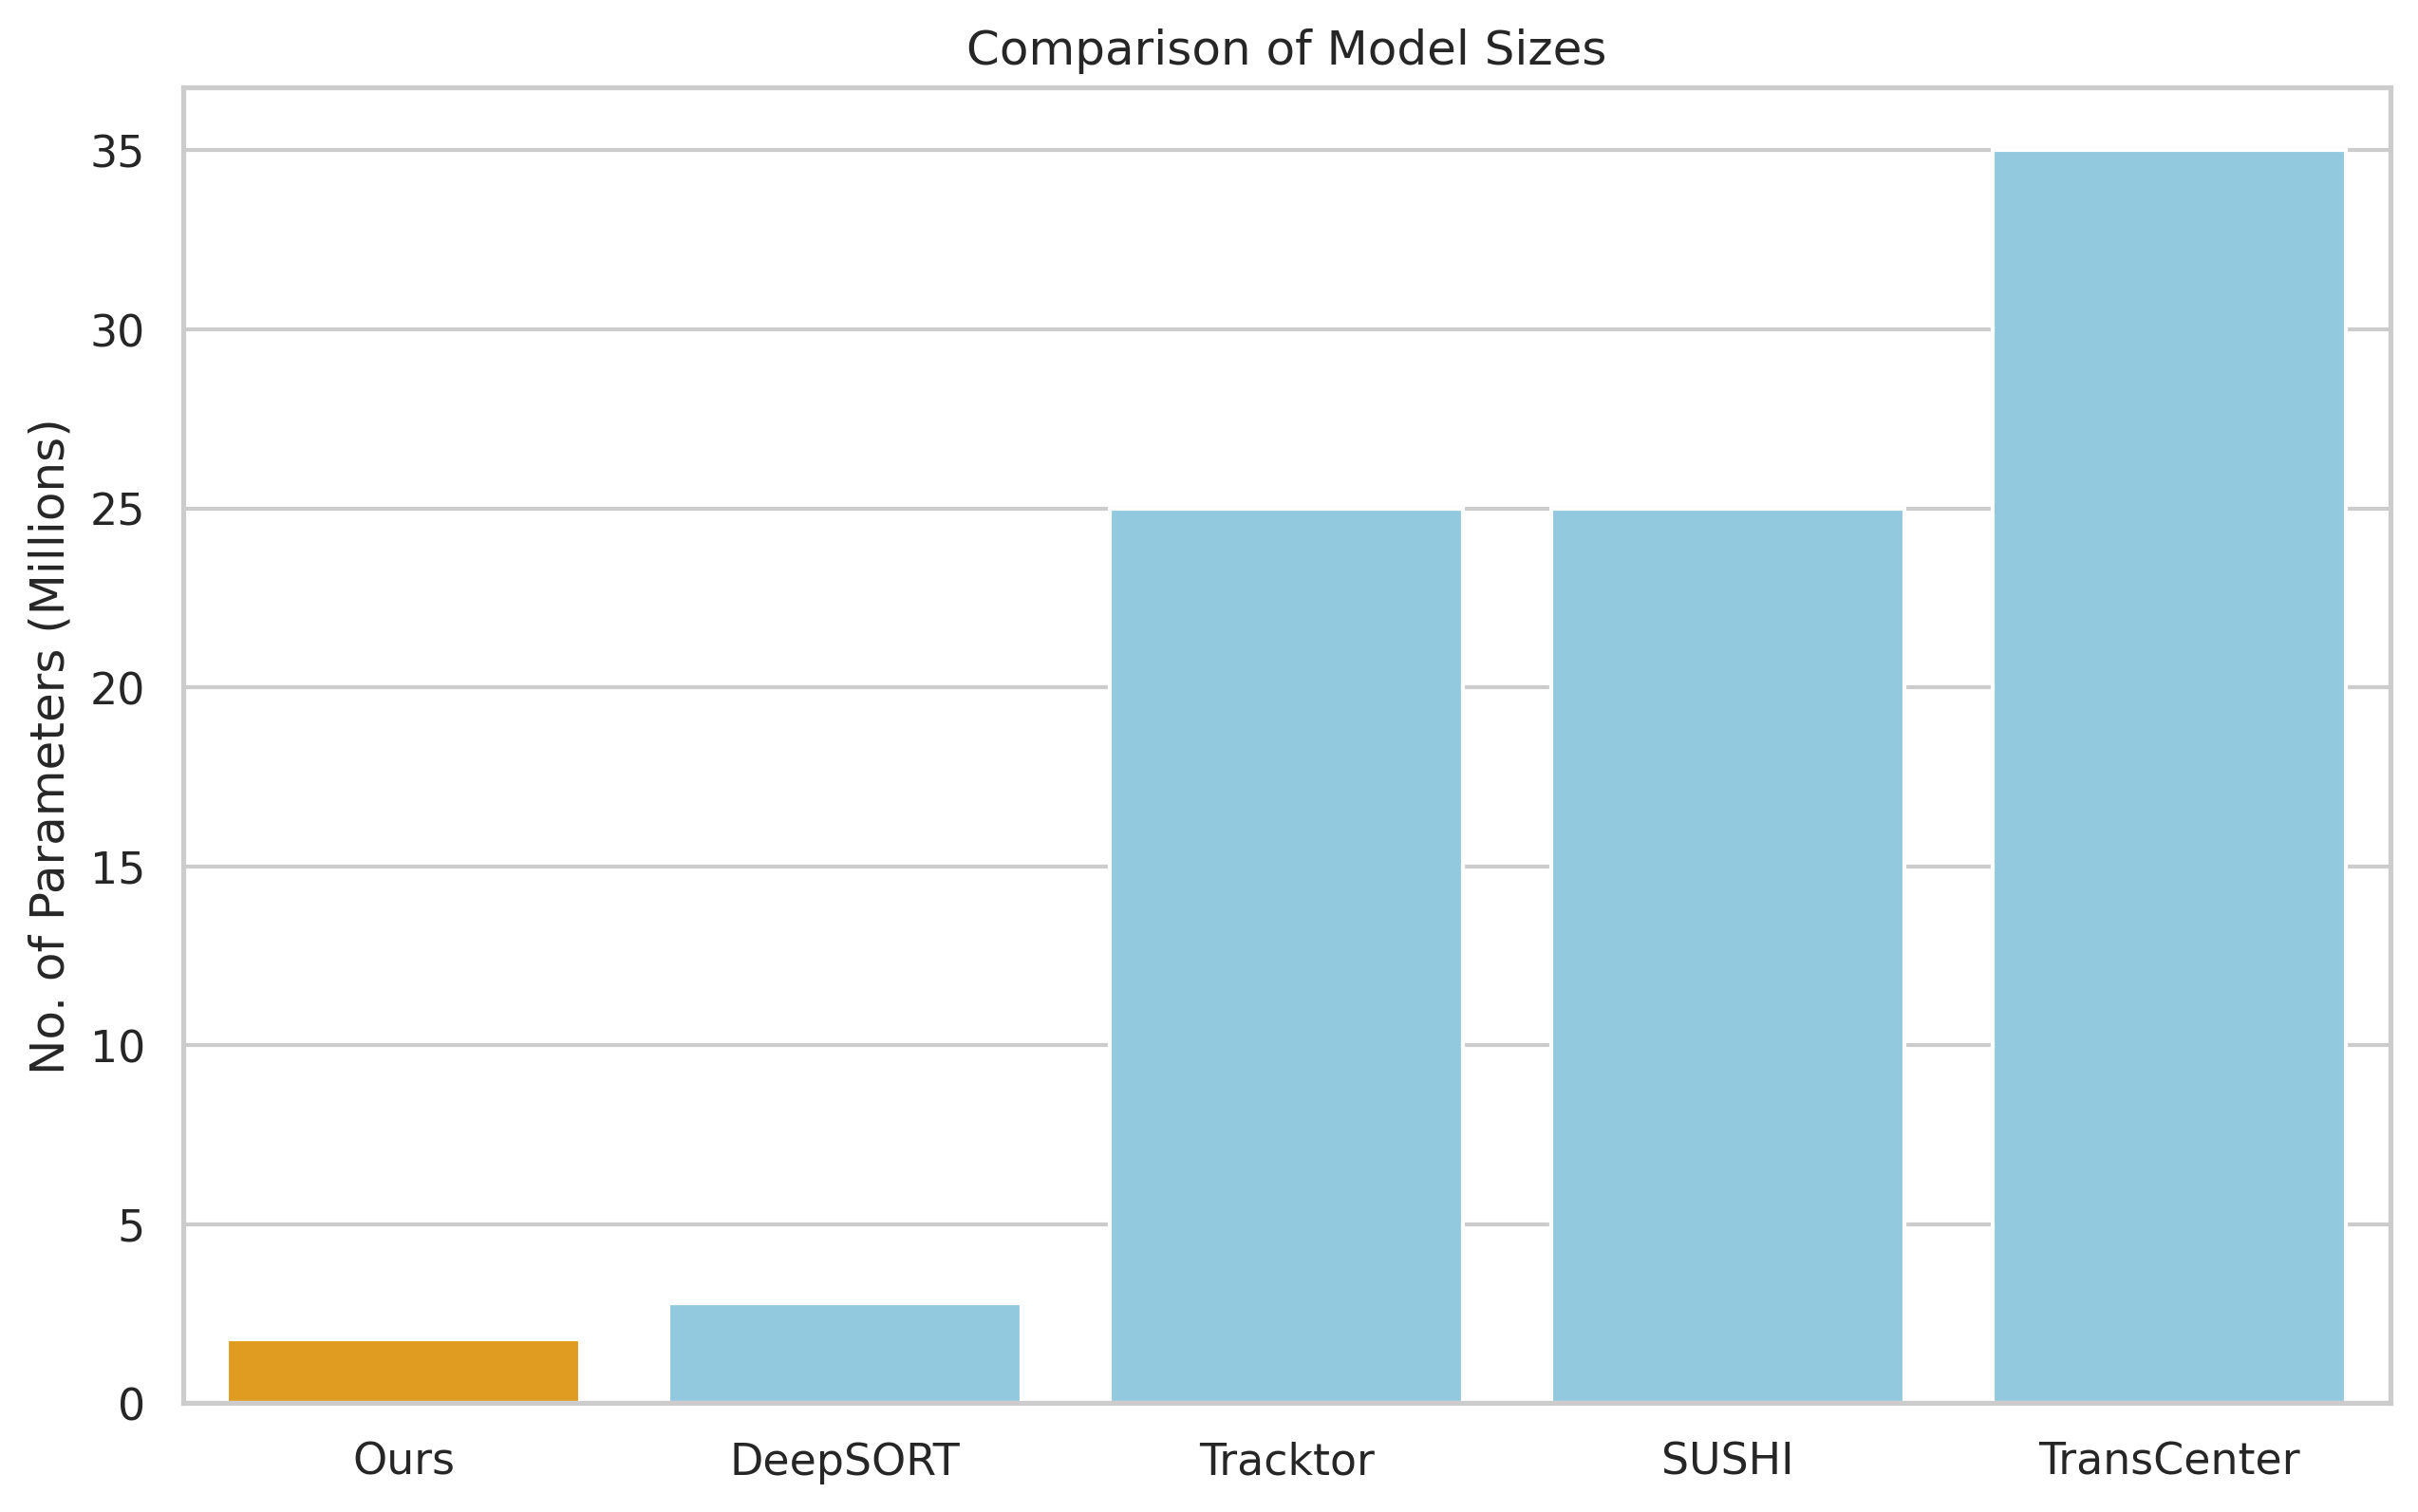

In [40]:
number_of_parameters = pd.Series(data={"Ours": 1.8, "DeepSORT": 2.8, "Tracktor": 25, "SUSHI": 25, "TransCenter": 35})

# Convert the series to a DataFrame
df = number_of_parameters.reset_index()
df.columns = ['Model', 'Size']

# Set the colors.
colors = ['skyblue'] * len(df)
# Make the "Ours" column stand out.
specific_bar_index = df[df['Model'] == 'Ours'].index[0]
colors[specific_bar_index] = 'orange'

# Create the bar plot
plt.figure(figsize=(10, 6), dpi=300)
barplot = sns.barplot(x='Model', y='Size', data=df, palette=colors)

# Set labels and title
barplot.set_xlabel('')
barplot.set_ylabel('No. of Parameters (Millions)')
plt.title('Comparison of Model Sizes')

# Show the plot
plt.show()

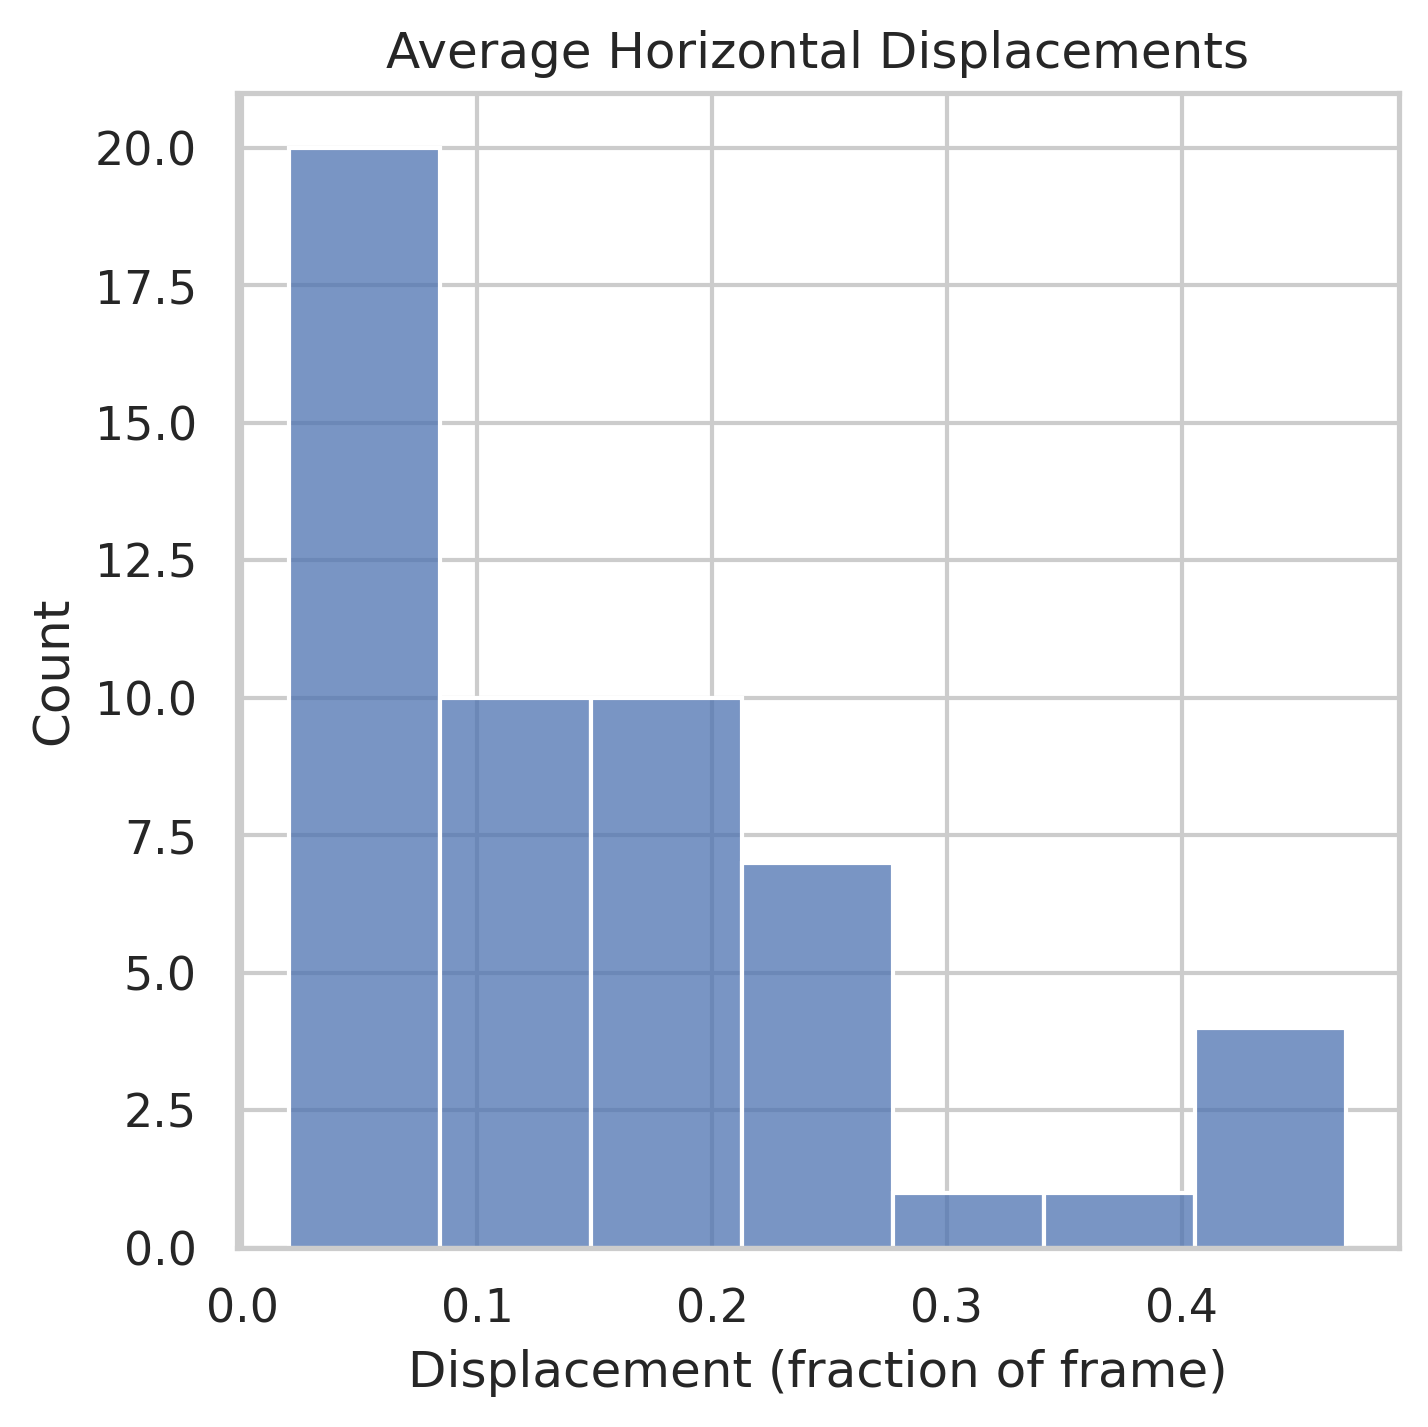

In [39]:
horizontal_displacements = [0.02] * 20 + [0.1] * 10 + [0.17] * 10 + [0.22] * 7 + [0.3] + [0.375] + [0.47] * 4

plt.figure(figsize=(5, 5), dpi=300)
sns.histplot(horizontal_displacements, bins=7)
plt.title("Average Horizontal Displacements")
plt.xlabel("Displacement (fraction of frame)")
plt.ylabel("Count")

plt.show()

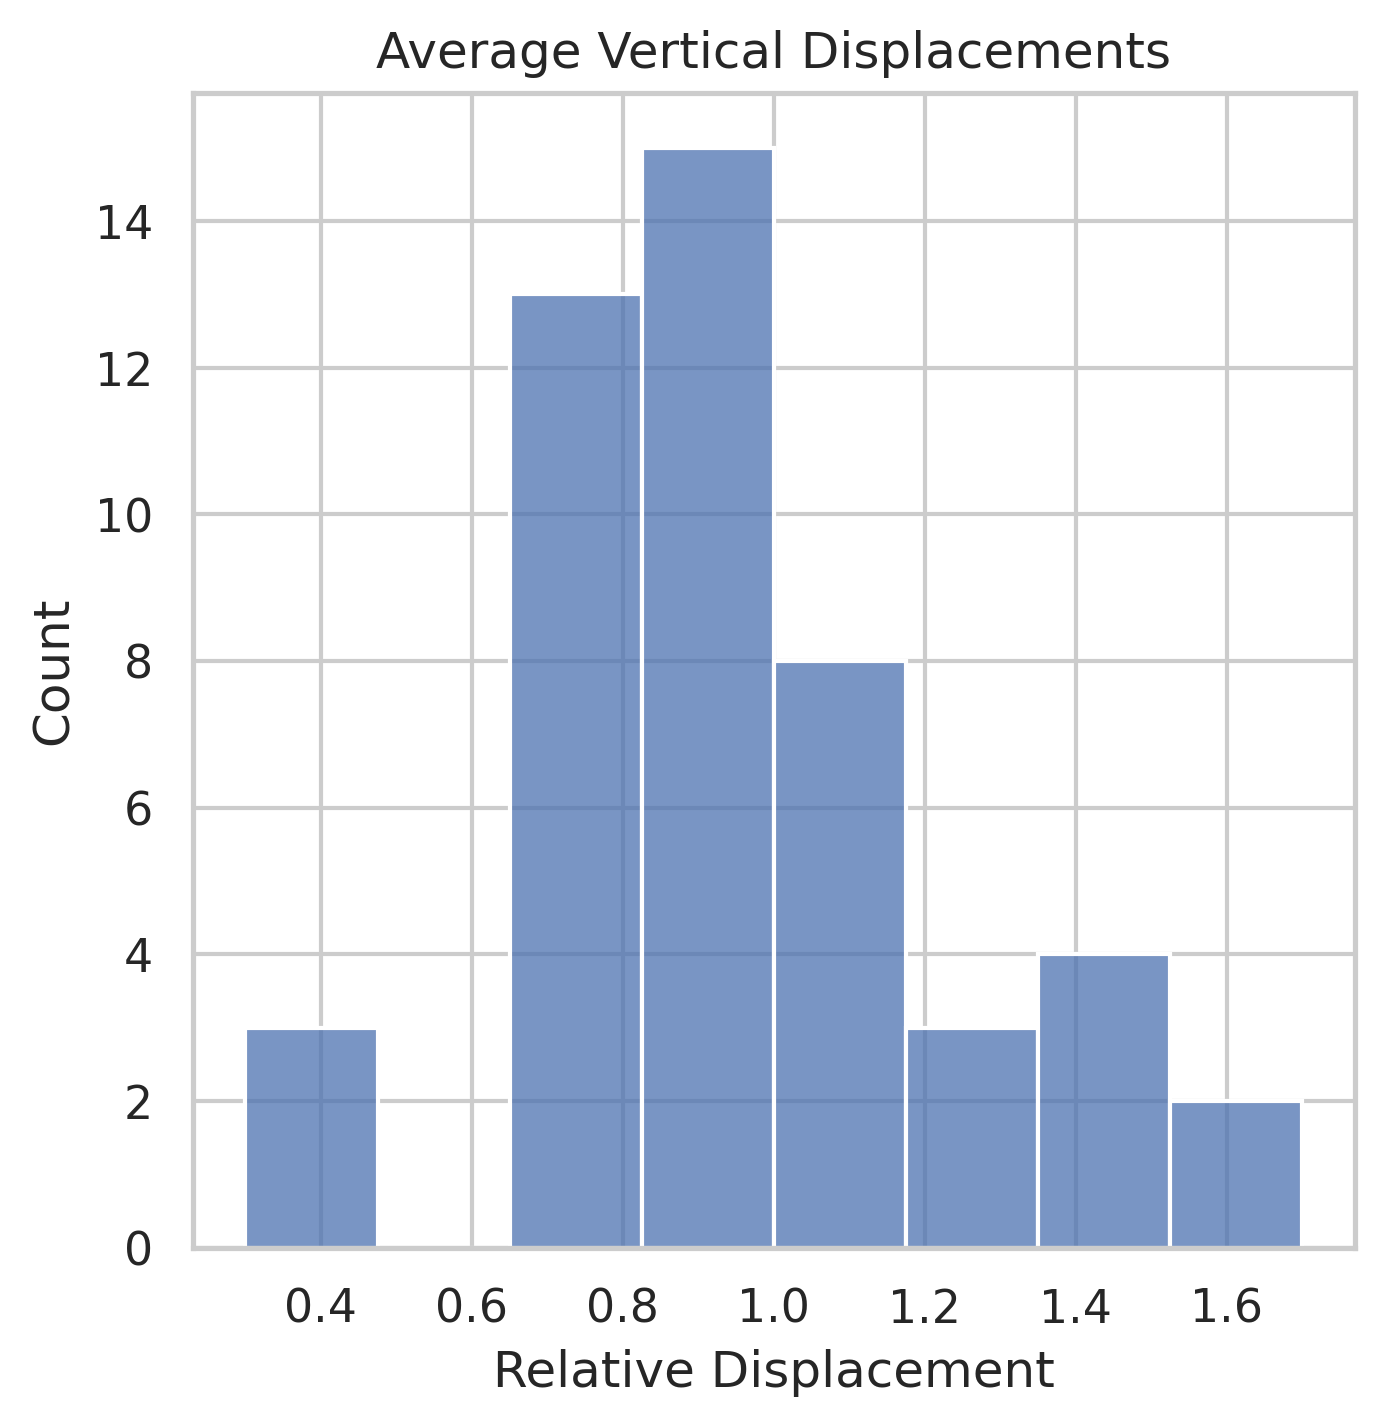

In [34]:
vertical_displacements = [0.3] * 3 + [0.65] * 2 + [0.8] * 11 + [0.95] * 15 + [1.15] * 8 + [1.3] * 3 + [1.5] * 4 + [1.7] * 2

plt.figure(figsize=(5, 5), dpi=300)
sns.histplot(vertical_displacements, bins=8)
plt.title("Average Vertical Displacements")
plt.xlabel("Relative Displacement")
plt.ylabel("Count")

plt.show()